-------------------------------------------------------------------------------

CHIBO 2024

An attempt to static calculate the forces in (x,y,z) at all the suspension pickup points for various roll/jounce effects

18.12.2024: Created

-------------------------------------------------------------------------------

In [1]:
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [2]:
# Declare motions for evaluation

# Define maximum roll and jounce inputs
body_roll = 10  # Maximum roll angle in degrees
body_jounce = 0.05  # Maximum jounce in meters (5 cm)

# Generate roll and jounce motion inputs
roll_angles = np.linspace(0, np.radians(body_roll), 100)  # 0 to max roll angle in 100 steps
jounce_displacements = np.linspace(0, body_jounce, 100)  # 0 to max jounce in 100 steps

# Check roll_angles and jounce_displacements
print("Roll Angles (rad):", roll_angles[:5], "...", roll_angles[-5:])
print("Jounce Displacements (m):", jounce_displacements[:5], "...", jounce_displacements[-5:])


Roll Angles (rad): [0.         0.00176296 0.00352592 0.00528888 0.00705184] ... [0.16748109 0.16924405 0.17100701 0.17276997 0.17453293]
Jounce Displacements (m): [0.         0.00050505 0.0010101  0.00151515 0.0020202 ] ... [0.0479798  0.04848485 0.0489899  0.04949495 0.05      ]


In [27]:
# Suspension pickup points
#                          x      y    z
upper_a_arm = np.array([
    [0.0015, 0.5065, 0.315],  # Outer point (converted from mm to m)
    [-0.135, 0.240, 0.220],   # Inner leading point
    [0.180, 0.255, 0.255]     # Inner trailing point
])

lower_a_arm = np.array([
    [-0.0175, 0.519, 0.137],  # Outer point
    [-0.180, 0.165, 0.087],   # Inner leading point
    [0.180, 0.170, 0.087]     # Inner trailing point
])

tie_rod = np.array([
    [0.060, 0.515, 0.160],  # Outer point
    [0.070, 0.195, 0.100]   # Inner point
])

tire_cop = np.array([-0.005, 0.525, 0])  # Converted from mm to m
force_vector = np.array([50, 500, -2000.0])  # Force at the CoP (N)


In [11]:
def calculate_lengths(points):
    """
    Calculate lengths between the specified points in a given array.

    Parameters:
        points (np.array): An array of points (Nx3), where the first point is the outer point,
                           and the remaining are inner points.

    Returns:
        dict: A dictionary containing the lengths between the outer point and the inner points,
              as well as the distance between the outer points of the upper and lower A-arms
              and the tie rod.
    """
    outer_point = points[0]
    inner_points = points[1:]
    
    # Lengths from outer point to inner points
    lengths_to_inner = np.linalg.norm(inner_points - outer_point, axis=1)
    
    return lengths_to_inner

# Calculate lengths for upper and lower A-arms and tie rod
upper_lengths = calculate_lengths(upper_a_arm)
lower_lengths = calculate_lengths(lower_a_arm)

# Distance between the outer points of the upper and lower A-arms and tie rod
outer_distances = {
    "upper_to_lower": np.linalg.norm(upper_a_arm[0] - lower_a_arm[0]),
    "upper_to_tie": np.linalg.norm(upper_a_arm[0] - tie_rod[0]),
    "lower_to_tie": np.linalg.norm(lower_a_arm[0] - tie_rod[0])
}

# Output results
print("Upper A-arm lengths (outer to inner points):", upper_lengths)
print("Lower A-arm lengths (outer to inner points):", lower_lengths)
print("Distances between outer points (upper, lower, tie rod):", outer_distances)


Upper A-arm lengths (outer to inner points): [0.31413293 0.31418864]
Lower A-arm lengths (outer to inner points): [0.39271141 0.40411292]
Distances between outer points (upper, lower, tie rod): {'upper_to_lower': 0.17944706740429056, 'upper_to_tie': 0.16589002381095735, 'lower_to_tie': 0.08093979243857746}


In [7]:
def calculate_roll_center(upper, lower, cop):
    """
    Calculate the roll center (RC) based on 3D suspension geometry and tire CoP.
    Assumes suspension symmetry about the vehicle centerline.

    Parameters:
        upper (np.ndarray): 3x3 matrix of upper control arm pickup points.
                           [[outer], [inner front], [inner rear]] points.
        lower (np.ndarray): 3x3 matrix of lower control arm pickup points.
                           [[outer], [inner front], [inner rear]] points.
        cop (np.ndarray): 1x3 array for tire center of pressure (CoP).

    Returns:
        np.ndarray: Roll center coordinates [x, y, z] in the global coordinate system.
        dict: Additional geometry data including instant centers and angles.
    """
    # Input validation
    if not all(isinstance(x, np.ndarray) for x in [upper, lower, cop]):
        raise ValueError("Inputs must be numpy arrays")
    if upper.shape != (3, 3) or lower.shape != (3, 3):
        raise ValueError("Control arm matrices must be 3x3")
    if cop.shape != (3,):
        raise ValueError("CoP must be 1x3 array")

    # Calculate control arm planes normal vectors
    def get_plane_normal(points):
        """Calculate normal vector of plane defined by three points."""
        v1 = points[1] - points[0]
        v2 = points[2] - points[0]
        return np.cross(v1, v2)

    upper_normal = get_plane_normal(upper)
    lower_normal = get_plane_normal(lower)

    # Project arms onto front view (XZ plane)
    upper_outer_2d = upper[0, [0, 2]]  # [x, z]
    upper_inner_2d = upper[1, [0, 2]]  # Using front inner point
    lower_outer_2d = lower[0, [0, 2]]
    lower_inner_2d = lower[1, [0, 2]]
    tire_cop_2d = cop[[0, 2]]

    # Calculate control arm angles in front view
    def get_arm_angle(outer, inner):
        """Calculate arm angle from horizontal in front view."""
        delta = inner - outer
        return np.degrees(np.arctan2(delta[1], delta[0]))

    upper_angle = get_arm_angle(upper_outer_2d, upper_inner_2d)
    lower_angle = get_arm_angle(lower_outer_2d, lower_inner_2d)

    # Find instant center (IC) in front view
    def line_equation(p1, p2):
        """Return slope and intercept of line through two points."""
        m = (p2[1] - p1[1]) / (p2[0] - p1[0])
        c = p1[1] - m * p1[0]
        return m, c

    m_upper, c_upper = line_equation(upper_outer_2d, upper_inner_2d)
    m_lower, c_lower = line_equation(lower_outer_2d, lower_inner_2d)
    
    ic_x = (c_lower - c_upper) / (m_upper - m_lower)
    ic_z = m_upper * ic_x + c_upper
    instant_center_2d = np.array([ic_x, ic_z])

    # Calculate roll center height
    # RC is where line from IC to CoP intersects vehicle centerline (x=0)
    m_ic_to_cop = (tire_cop_2d[1] - ic_z) / (tire_cop_2d[0] - ic_x)
    c_ic_to_cop = ic_z - m_ic_to_cop * ic_x
    rc_z = c_ic_to_cop  # At x=0

    # Consider 3D effects
    # Calculate swing arm length (SAL) considering y-axis position
    sal = np.sqrt(ic_x**2 + (upper[1, 1] - upper[0, 1])**2)  # Using y-distance
    
    # Calculate roll center including y-coordinate
    # Using average y-position of inner pickup points
    rc_y = (np.mean(upper[:, 1]) + np.mean(lower[:, 1])) / 2
    
    roll_center = np.array([0, rc_y, rc_z])

    # Package additional geometry data
    geometry_data = {
        'instant_center_2d': instant_center_2d,
        'swing_arm_length': sal,
        'upper_arm_angle': upper_angle,
        'lower_arm_angle': lower_angle,
        'upper_normal': upper_normal,
        'lower_normal': lower_normal
    }

    return roll_center, geometry_data

# Example usage:
def example_usage():
    # Example suspension geometry (in mm)
    rc, geometry = calculate_roll_center(upper_a_arm, lower_a_arm, tire_cop)
    print("Roll Center [x, y, z]:", rc)
    print("\nGeometry Data:")
    for key, value in geometry.items():
        print(f"{key}:", value)


example_usage()
roll_centre = calculate_roll_center(upper_a_arm, lower_a_arm, tire_cop)


Roll Center [x, y, z]: [ 0.00000000e+00  3.09250000e-01 -7.35029077e-05]

Geometry Data:
instant_center_2d: [-0.44187736  0.00642235]
swing_arm_length: 0.5160211719945224
upper_arm_angle: -145.16321429220443
lower_arm_angle: -162.89727103094762
upper_normal: [-0.0079025 -0.0251475  0.0819   ]
lower_normal: [ 0.00025   -0.018      0.1266275]


In [40]:
def rotate_points(points, axis_point, rotation_axis, angle):
    """
    Rotate points around a given axis in 3D space.

    Parameters:
        points (np.array): Nx3 array of points to be rotated.
        axis_point (np.array): A point on the rotation axis (3D).
        rotation_axis (np.array): Direction vector of the rotation axis (3D).
        angle (float): Rotation angle in radians.

    Returns:
        np.array: Rotated points.
    """
    # Normalize the rotation axis
    rotation_axis = rotation_axis / np.linalg.norm(rotation_axis)
    
    # Translate points to the rotation axis origin
    translated_points = points - axis_point
    
    # Compute the rotation matrix using the Rodrigues' rotation formula
    K = np.array([[0, -rotation_axis[2], rotation_axis[1]],
                  [rotation_axis[2], 0, -rotation_axis[0]],
                  [-rotation_axis[1], rotation_axis[0], 0]])
    
    I = np.eye(3)
    R = I + np.sin(angle) * K + (1 - np.cos(angle)) * (K @ K)
    
    # Apply rotation and translate back
    rotated_points = (R @ translated_points.T).T + axis_point
    return rotated_points

def calculate_outer_points(inner_points, outer_point, lengths):
    """
    Calculate new outer points based on rotated inner points and original lengths.

    Parameters:
        inner_points (np.array): Nx3 array of rotated inner points.
        outer_point (np.array): Original outer point (1x3 array).
        lengths (np.array): Distances from the outer point to each inner point.

    Returns:
        np.array: New outer point coordinates.
    """
    # Direction vectors from the inner points to the outer point
    directions = outer_point - inner_points
    
    # Normalize the directions
    normalized_directions = directions / np.linalg.norm(directions, axis=1)[:, None]
    
    # Calculate the new outer points
    new_outer_points = inner_points + normalized_directions * lengths[:, None]
    return new_outer_points

In [42]:
# Example usage

# Initialize rotated_upper as a copy of the original upper_a_arm
rotated_upper = upper_a_arm.copy()
rotated_lower = lower_a_arm.copy()

# Rotation inputs
roll_center = np.array([0, 0, 0.2])  # Example roll center (m)
roll_axis = np.array([1, 0, 0])         # Example roll axis (x-axis)
roll_angle = np.radians(2)              # Example roll angle (2 degrees)

# Rotate the inner points
rotated_upper_inner = rotate_points(upper_a_arm[1:], roll_center, roll_axis, roll_angle)
rotated_lower_inner = rotate_points(lower_a_arm[1:], roll_center, roll_axis, roll_angle)

rotated_upper[1:] = rotated_upper_inner
rotated_lower[1:] = rotated_lower_inner

# Output the results
print("Upper points:\n", upper_a_arm)
print("Rotated Upper points:\n", rotated_upper)

print("Lower points:\n", lower_a_arm)
print("Rotated Lower points:\n", rotated_lower)
# print("New upper outer point:\n", new_upper_outer)
# print("New lower outer point:\n", new_lower_outer)

Upper points:
 [[ 0.0015  0.5065  0.315 ]
 [-0.135   0.24    0.22  ]
 [ 0.18    0.255   0.255 ]]
Rotated Upper points:
 [[ 0.0015      0.5065      0.315     ]
 [-0.135       0.23915581  0.2283637 ]
 [ 0.18        0.25292519  0.26386587]]
Lower points:
 [[-0.0175  0.519   0.137 ]
 [-0.18    0.165   0.087 ]
 [ 0.18    0.17    0.087 ]]
Rotated Lower points:
 [[-0.0175      0.519       0.137     ]
 [-0.18        0.16884313  0.09282725]
 [ 0.18        0.17384008  0.09300175]]


In [43]:
def plot_suspension_interactive(upper, lower, upper_rot, low_rot, tie, cop):
    fig = go.Figure()

    # Upper A-arm
    fig.add_trace(go.Scatter3d(
        x=[upper[0, 0], upper[1, 0]], y=[upper[0, 1], upper[1, 1]], z=[upper[0, 2], upper[1, 2]],
        mode='lines+markers',
        name='Upper A-arm (Outer to Inner Leading)',
        marker=dict(size=6, color='blue'),
        line=dict(color='blue', width=2)
    ))
    fig.add_trace(go.Scatter3d(
        x=[upper[0, 0], upper[2, 0]], y=[upper[0, 1], upper[2, 1]], z=[upper[0, 2], upper[2, 2]],
        mode='lines+markers',
        name='Upper A-arm (Outer to Inner Trailing)',
        line=dict(color='blue', width=2)
    ))
    fig.add_trace(go.Scatter3d(
        x=[upper[1, 0], upper[2, 0]], y=[upper[1, 1], upper[2, 1]], z=[upper[1, 2], upper[2, 2]],
        mode='lines',
        name='Upper A-arm (Inner leading to Inner Trailing)',
        line=dict(color='blue', width=2, dash='dot')
    ))
    
# Rotated Upper A-arm
    fig.add_trace(go.Scatter3d(
        x=[upper_rot[0, 0], upper_rot[1, 0]], y=[upper_rot[0, 1], upper_rot[1, 1]], z=[upper_rot[0, 2], upper_rot[1, 2]],
        mode='lines+markers',
        name='Upper A-arm (Rot Outer to Inner Leading)',
        marker=dict(size=6, color='purple'),
        line=dict(color='purple', width=2)
    ))
    fig.add_trace(go.Scatter3d(
        x=[upper_rot[0, 0], upper_rot[2, 0]], y=[upper_rot[0, 1], upper_rot[2, 1]], z=[upper_rot[0, 2], upper_rot[2, 2]],
        mode='lines+markers',
        name='Upper A-arm (Rot Outer to Inner Trailing)',
        marker=dict(size=6, color='purple'),
        line=dict(color='purple', width=2)
    ))
    fig.add_trace(go.Scatter3d(
        x=[upper_rot[1, 0], upper_rot[2, 0]], y=[upper_rot[1, 1], upper_rot[2, 1]], z=[upper_rot[1, 2], upper_rot[2, 2]],
        mode='lines',
        name='Upper A-arm (Rot Inner leading to Inner Trailing)',
        line=dict(color='purple', width=2, dash='dot')
    ))

    # Lower A-arm
    fig.add_trace(go.Scatter3d(
        x=[lower[0, 0], lower[1, 0]], y=[lower[0, 1], lower[1, 1]], z=[lower[0, 2], lower[1, 2]],
        mode='lines+markers',
        name='Lower A-arm (Outer to Inner Leading)',
        marker=dict(size=6, color='green'),
        line=dict(color='green', width=2)
    ))
    fig.add_trace(go.Scatter3d(
        x=[lower[0, 0], lower[2, 0]], y=[lower[0, 1], lower[2, 1]], z=[lower[0, 2], lower[2, 2]],
        mode='lines+markers',
        name='Lower A-arm (Outer to Inner Trailing)',
        line=dict(color='green', width=2)
    ))
    fig.add_trace(go.Scatter3d(
        x=[lower[1, 0], lower[2, 0]], y=[lower[1, 1], lower[2, 1]], z=[lower[1, 2], lower[2, 2]],
        mode='lines',
        name='lower A-arm (Inner leading to Inner Trailing)',
        line=dict(color='green', width=2, dash='dot')
    ))

    # Tie rod
    fig.add_trace(go.Scatter3d(
        x=[tie[0, 0], tie[1, 0]], y=[tie[0, 1], tie[1, 1]], z=[tie[0, 2], tie[1, 2]],
        mode='lines+markers',
        name='Tie Rod',
        marker=dict(size=6, color='red'),
        line=dict(color='red', width=2)
    ))

    # Tire CoP
    fig.add_trace(go.Scatter3d(
        x=[cop[0]], y=[cop[1]], z=[cop[2]],
        mode='markers',
        name='Tire CoP',
        marker=dict(size=8, color='orange')
    ))

    # Set axis labels
    fig.update_layout(
        title="Interactive Suspension Geometry (Corrected Connections)",
        scene=dict(
            xaxis_title="X (m)",
            yaxis_title="Y (m)",
            zaxis_title="Z (m)"
        )
    )

    fig.show()

# Example usage
plot_suspension_interactive(upper_a_arm, lower_a_arm, rotated_upper, rotated_lower, tie_rod, tire_cop)


Ok need to fix code below: 1. dont think the roll code is good, it needs to hold the link length as a constand and pull/push the outer point accordingly, upper and lower at the same time to preserve the knuckle length. 2. force calc looks wrong? reaction loads can only be along 'polar ray;3. Setup so it runs one step of roll/jounce then recalcs the rc, forces, adds points and forces to array

In [45]:
def calculate_reaction_forces(upper, lower, tie, cop, force_vector, roll_center):
    """
    Calculate the reaction forces at suspension inner points based on equilibrium.
    
    Parameters:
        upper (np.array): Upper A-arm points (3x3).
        lower (np.array): Lower A-arm points (3x3).
        tie (np.array): Tie rod points (2x3).
        cop (np.array): Tire CoP point (1x3).
        force_vector (np.array): Tire CoP force vector (1x3).
        roll_center (np.array): Roll center coordinates (1x3).
        
    Returns:
        dict: Reaction forces at inner points (upper, lower, tie).
    """
    # Define all link axes (normalized vectors)
    upper_axes = (upper[0] - upper[1:]) / np.linalg.norm(upper[0] - upper[1:], axis=1)[:, None]
    lower_axes = (lower[0] - lower[1:]) / np.linalg.norm(lower[0] - lower[1:], axis=1)[:, None]
    tie_axis = (tie[0] - tie[1]) / np.linalg.norm(tie[0] - tie[1])

    # Combine all axes into one system
    axes = np.vstack([upper_axes, lower_axes, tie_axis[None]])

    # Set up equilibrium equations (forces)
    A_forces = axes.T
    b_forces = -force_vector  # Tire CoP force opposes suspension reactions

    # Moments about roll center
    upper_moments = np.cross(upper[1:] - roll_center, upper_axes)
    lower_moments = np.cross(lower[1:] - roll_center, lower_axes)
    tie_moment = np.cross(tie[1] - roll_center, tie_axis)

    A_moments = np.vstack([upper_moments, lower_moments, tie_moment[None]])
    b_moments = -np.cross(cop - roll_center, force_vector)

    # Combine force and moment equations
    A = np.vstack([A_forces, A_moments])
    b = np.hstack([b_forces, b_moments])

    # Solve for forces
    forces = np.linalg.lstsq(A, b, rcond=None)[0]

    # Map forces back to components
    return {
        "upper": forces[:2],
        "lower": forces[2:4],
        "tie": forces[4]
    }



# Example usage for one roll/jounce combination
reactions = calculate_reaction_forces(upper_a_arm, lower_a_arm, tie_rod, tire_cop, force_vector, roll_centre)
print("Reaction forces (N):", reactions)

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (2,) + inhomogeneous part.

In [34]:
# Storage for transformed pickup points and forces
upper_inner_forces = []
lower_inner_forces = []

# Iterate through roll and jounce motions
for roll_angle, jounce_disp in zip(roll_angles, jounce_displacements):
    # Apply roll and jounce transformations
    upper_transformed = apply_jounce(apply_roll_about_axis(upper_a_arm, roll_angle, roll_center), jounce_disp)
    lower_transformed = apply_jounce(apply_roll_about_axis(lower_a_arm, roll_angle, roll_center), jounce_disp)
    
    # Resolve forces at the inner pickup points (split evenly as placeholder)
    upper_force = resolve_forces(force_vector)
    lower_force = resolve_forces(force_vector)
    
    # Store resolved forces
    upper_inner_forces.append(upper_force)
    lower_inner_forces.append(lower_force)

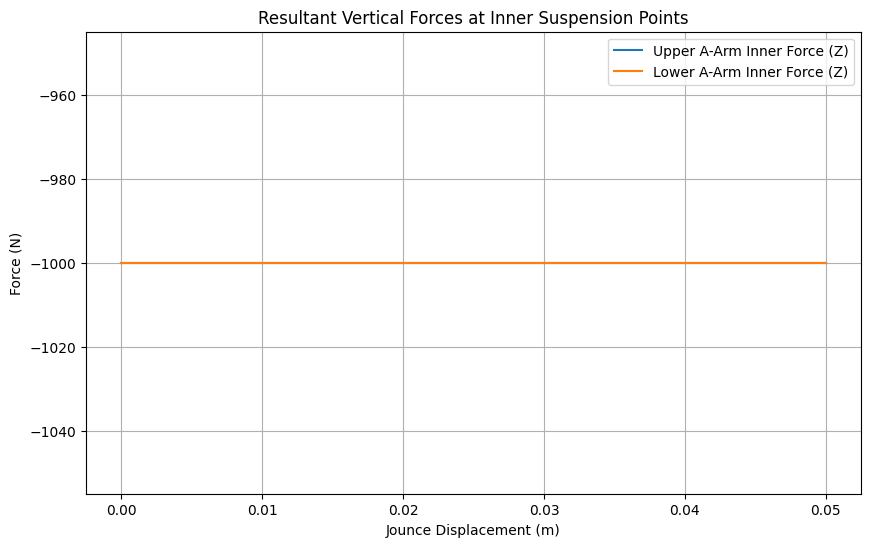

In [35]:
# Extract z-force (vertical) components for plotting
upper_z_forces = [force[2] for force in upper_inner_forces]
lower_z_forces = [force[2] for force in lower_inner_forces]

# Plot forces vs. motion
plt.figure(figsize=(10, 6))
plt.plot(jounce_displacements, upper_z_forces, label="Upper A-Arm Inner Force (Z)")
plt.plot(jounce_displacements, lower_z_forces, label="Lower A-Arm Inner Force (Z)")
plt.xlabel("Jounce Displacement (m)")
plt.ylabel("Force (N)")
plt.title("Resultant Vertical Forces at Inner Suspension Points")
plt.legend()
plt.grid()
plt.show()